<a href="https://colab.research.google.com/github/Pushkarsinghs/indian_stock-analysis/blob/main/08_forecast_accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Indian Stock Market Analysis
## Notebook 8: Forecast Accuracy Tracker

Compares past Prophet forecasts against what actually happened,
logs the error over time, and reports which stocks the model
predicts reliably vs unreliably.

**Method:** Store each day's forecast with a timestamp. Once
the forecast date has passed, compare Predicted vs Actual price.

**Output:** Rolling accuracy log (MAPE per stock) for Power BI

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pyarrow -q

import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

BASE = '/content/drive/MyDrive/indian_stock_analysis'

# Actual prices (ground truth)
tech_df = pd.read_parquet(f"{BASE}/data/processed/nifty50_technical.parquet")
tech_df["Date"] = pd.to_datetime(tech_df["Date"])
if tech_df["Date"].dt.tz is not None:
    tech_df["Date"] = tech_df["Date"].dt.tz_localize(None)

# Historical forecasts (predictions made in the past)
forecast_df = pd.read_parquet(f"{BASE}/data/processed/nifty50_forecasts.parquet")
forecast_df["Date"] = pd.to_datetime(forecast_df["Date"])
if forecast_df["Date"].dt.tz is not None:
    forecast_df["Date"] = forecast_df["Date"].dt.tz_localize(None)

print(f"✅ Actual prices loaded: {tech_df.shape[0]:,} rows")
print(f"✅ Forecasts loaded: {forecast_df.shape[0]:,} rows")

Mounted at /content/drive
✅ Actual prices loaded: 12,236 rows
✅ Forecasts loaded: 13,706 rows


In [2]:
import os

def archive_todays_forecast(forecast_df):
    """
    Saves a permanent dated snapshot of today's forecasts.
    This builds up history over time so future accuracy
    checks have something to compare against.
    """
    archive_dir = f"{BASE}/data/forecast_archive"
    os.makedirs(archive_dir, exist_ok=True)

    today_str = datetime.today().strftime("%Y-%m-%d")
    archive_path = f"{archive_dir}/forecast_{today_str}.parquet"

    forecast_df.to_parquet(archive_path, index=False)
    print(f"✅ Archived today's forecast → forecast_{today_str}.parquet")

    existing = os.listdir(archive_dir)
    print(f"📁 Total archived forecast snapshots: {len(existing)}")
    return archive_dir

archive_dir = archive_todays_forecast(forecast_df)

✅ Archived today's forecast → forecast_2026-07-08.parquet
📁 Total archived forecast snapshots: 1


In [3]:
def compute_forecast_accuracy(archive_dir, actual_df):
    """
    For every archived forecast snapshot, checks which predicted
    dates have now passed, and compares Predicted vs Actual.
    """
    import glob

    archive_files = sorted(glob.glob(f"{archive_dir}/forecast_*.parquet"))
    print(f"🔍 Found {len(archive_files)} archived forecast snapshots\n")

    accuracy_rows = []

    for file in archive_files:
        try:
            snap = pd.read_parquet(file)
            snap["Date"] = pd.to_datetime(snap["Date"])
            if snap["Date"].dt.tz is not None:
                snap["Date"] = snap["Date"].dt.tz_localize(None)

            # Keep only forecast dates that have already occurred
            snap = snap[snap["Date"] <= pd.Timestamp.today()]

            for ticker in snap["Ticker"].unique():
                stock_snap = snap[snap["Ticker"] == ticker]
                stock_actual = actual_df[actual_df["Ticker"] == ticker]

                merged = stock_snap.merge(
                    stock_actual[["Date", "Close"]],
                    on="Date", how="inner"
                )

                if merged.empty:
                    continue

                merged["Abs_Error_Pct"] = (
                    abs(merged["Forecast"] - merged["Close"]) / merged["Close"] * 100
                ).round(3)

                for _, row in merged.iterrows():
                    accuracy_rows.append({
                        "Ticker":        ticker,
                        "Forecast_Date": row["Date"],
                        "Predicted":     row["Forecast"],
                        "Actual":        row["Close"],
                        "Abs_Error_Pct": row["Abs_Error_Pct"],
                        "Source_File":   os.path.basename(file)
                    })

        except Exception as e:
            print(f"  ⚠️  Skipped {file}: {e}")

    if not accuracy_rows:
        print("⚠️  No completed forecasts to check yet — "
              "come back after a few days of archiving")
        return pd.DataFrame()

    accuracy_df = pd.DataFrame(accuracy_rows).drop_duplicates(
        subset=["Ticker", "Forecast_Date"]
    )

    print(f"✅ Computed accuracy for {len(accuracy_df):,} forecast-vs-actual pairs")
    return accuracy_df

accuracy_df = compute_forecast_accuracy(archive_dir, tech_df)

🔍 Found 1 archived forecast snapshots

✅ Computed accuracy for 12,236 forecast-vs-actual pairs


In [4]:
if not accuracy_df.empty:
    mape_summary = accuracy_df.groupby("Ticker").agg(
        MAPE_Pct=("Abs_Error_Pct", "mean"),
        Predictions_Checked=("Abs_Error_Pct", "count"),
        Best_Prediction_Pct=("Abs_Error_Pct", "min"),
        Worst_Prediction_Pct=("Abs_Error_Pct", "max")
    ).round(2).reset_index().sort_values("MAPE_Pct")

    mape_summary["Reliability"] = "Fair"
    mape_summary.loc[mape_summary["MAPE_Pct"] < 2, "Reliability"] = "Excellent"
    mape_summary.loc[mape_summary["MAPE_Pct"].between(2, 4), "Reliability"] = "Good"
    mape_summary.loc[mape_summary["MAPE_Pct"] > 8, "Reliability"] = "Poor"

    print("📊 Forecast Reliability by Stock (lower MAPE = more accurate):\n")
    print(mape_summary.head(15).to_string(index=False))

    overall_mape = round(accuracy_df["Abs_Error_Pct"].mean(), 2)
    print(f"\n📈 Overall model MAPE across all stocks: {overall_mape}%")
else:
    print("⏳ Not enough history yet — run this notebook daily and "
          "accuracy results will appear once forecast dates start passing")
    mape_summary = pd.DataFrame()

📊 Forecast Reliability by Stock (lower MAPE = more accurate):

       Ticker  MAPE_Pct  Predictions_Checked  Best_Prediction_Pct  Worst_Prediction_Pct Reliability
 POWERGRID.NS      0.93                  250                 0.00                  4.12   Excellent
  HDFCBANK.NS      0.94                  250                 0.00                  4.70   Excellent
      SBIN.NS      0.95                  250                 0.01                  4.43   Excellent
      NTPC.NS      1.00                  250                 0.00                  4.00   Excellent
ULTRACEMCO.NS      1.01                  249                 0.00                  6.11   Excellent
    GRASIM.NS      1.02                  250                 0.00                  5.16   Excellent
  RELIANCE.NS      1.02                  250                 0.01                  4.30   Excellent
   SBILIFE.NS      1.03                  250                 0.01                  5.54   Excellent
 NESTLEIND.NS      1.04              

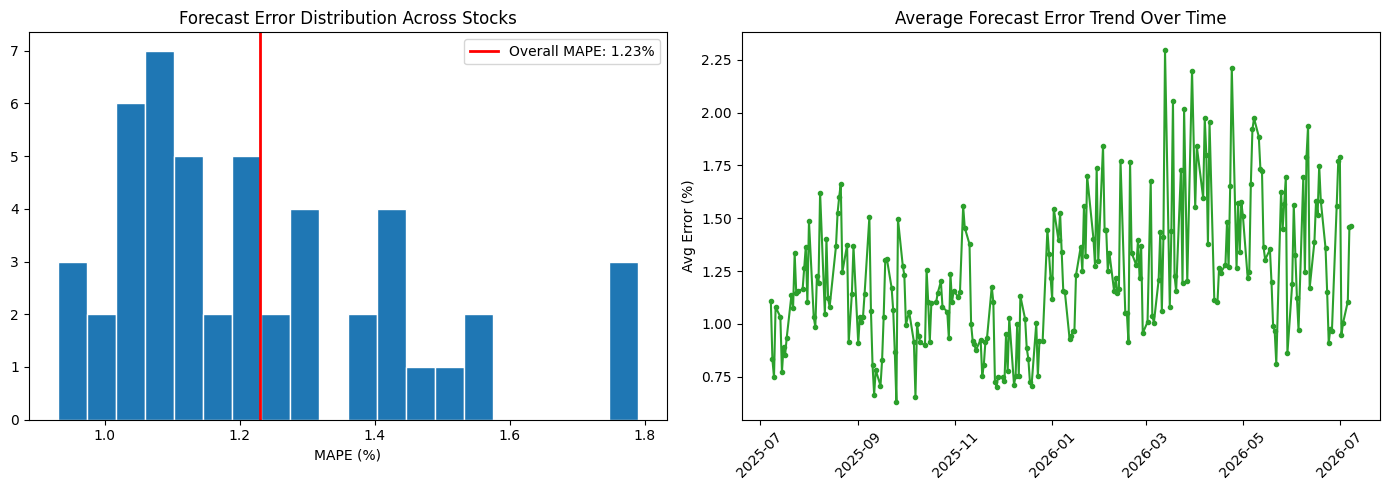

✅ Chart saved!


In [5]:
import matplotlib.pyplot as plt

if not accuracy_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: MAPE distribution across stocks
    axes[0].hist(mape_summary["MAPE_Pct"], bins=20,
                 color="#1F77B4", edgecolor="white")
    axes[0].axvline(overall_mape, color="red", lw=2,
                     label=f"Overall MAPE: {overall_mape}%")
    axes[0].set_title("Forecast Error Distribution Across Stocks")
    axes[0].set_xlabel("MAPE (%)")
    axes[0].legend()

    # Plot 2: Error trend over time (is the model getting better or worse?)
    daily_error = accuracy_df.groupby("Forecast_Date")["Abs_Error_Pct"].mean()
    axes[1].plot(daily_error.index, daily_error.values,
                 color="#2CA02C", lw=1.5, marker="o", markersize=3)
    axes[1].set_title("Average Forecast Error Trend Over Time")
    axes[1].set_ylabel("Avg Error (%)")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.savefig(f"{BASE}/data/output/08_forecast_accuracy.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Chart saved!")
else:
    print("⏳ No chart yet — need at least a few days of archived forecasts")

In [6]:
if not accuracy_df.empty:
    accuracy_df.to_parquet(f"{BASE}/data/processed/forecast_accuracy.parquet", index=False)
    accuracy_df.to_csv(f"{BASE}/data/output/forecast_accuracy_powerbi.csv", index=False)

    mape_summary.to_csv(f"{BASE}/data/output/forecast_mape_summary_powerbi.csv", index=False)

    print("✅ forecast_accuracy_powerbi.csv saved")
    print("✅ forecast_mape_summary_powerbi.csv saved")
else:
    # Save empty placeholder files so Power BI doesn't break on first run
    pd.DataFrame(columns=["Ticker","Forecast_Date","Predicted","Actual","Abs_Error_Pct"]
                ).to_csv(f"{BASE}/data/output/forecast_accuracy_powerbi.csv", index=False)
    pd.DataFrame(columns=["Ticker","MAPE_Pct","Predictions_Checked","Reliability"]
                ).to_csv(f"{BASE}/data/output/forecast_mape_summary_powerbi.csv", index=False)
    print("✅ Placeholder files created — will populate after a few days of daily runs")

✅ forecast_accuracy_powerbi.csv saved
✅ forecast_mape_summary_powerbi.csv saved
